In [1]:
!pip install nib

In [2]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

filepath = "BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001/BraTS20_Training_001_flair.nii"
img = nib.load(filepath)
data = img.get_fdata()
print(data.shape)
print(data.min(), data.max())
print(img.header)

(240, 240, 155)
0.0 625.0
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : np.bytes_(b'')
db_name         : np.bytes_(b'')
extents         : 0
session_error   : 0
regular         : np.bytes_(b'r')
dim_info        : 0
dim             : [  3 240 240 155   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : int16
bitpix          : 16
slice_start     : 0
pixdim          : [1. 1. 1. 1. 0. 0. 0. 0.]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 2
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : np.bytes_(b'')
aux_file        : np.bytes_(b'')
qform_code      : scanner
sform_code      : scanner
quatern_b       : 0.0
quatern_c       : 0.0
quatern_d       : 1.0
qoffset_x       : 0.0
qoffset_y       : 2

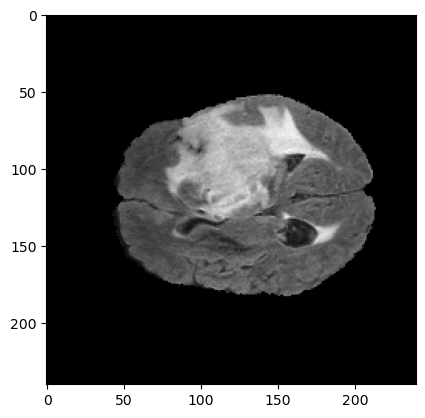

In [3]:
plt.imshow(data[:,:,75], cmap='gray')

## diffusion model
using a pretrained diffusion model

i don't have a good gpu :(

In [4]:
!pip install diffusers transformers accelerate

In [5]:
import os
from tqdm import tqdm
from diffusers import StableDiffusionPipeline

# stable diffusion model
pipe = StableDiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5").to("cuda")

output_folder = "generated_slices"
os.makedirs(output_folder, exist_ok=True)

prompts = {
    "flair": "FLAIR MRI scan of a human brain, high-resolution, medical imaging",
    "t1ce": "T1-weighted MRI scan with contrast enhancement, human brain, medical imaging",
    "t1": "T1-weighted MRI scan of a human brain, high-resolution",
    "t2": "T2-weighted MRI scan of a human brain, high contrast, medical imaging"
}

num_slices = 20
num_generated = 20

for i in range(num_generated):
    print(f"Generating MRI slices for sample {i+1}/{num_generated}")
    os.makedirs(f"{output_folder}/sample_{i+1}", exist_ok=True)
    for modality, prompt in prompts.items():
        print("Generating MRI slices for modality:", modality)

        slices = []
        for i in tqdm(range(num_slices), desc="Generating MRI Slices"):
            image = pipe(prompt).images[0]
            image = image.convert("L")
            image_path = os.path.join(output_folder, f"sample_{i+1}", f"{modality}_slice_{i:03d}.png")
            image.save(image_path)
            slices.append(np.array(image))

        volume = np.stack(slices, axis=-1)

        nii_img = nib.Nifti1Image(volume, affine=np.eye(4))
        nib.save(nii_img, f"{output_folder}/sample_{i+1}/{modality}_generated_brain.nii")

        print(f"NIfTI file saved as {output_folder}/sample_{i+1}/{modality}_generated_brain.nii")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Generating MRI slices for sample 1/20
Generating MRI slices for modality: flair


Generating MRI Slices:   0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Generating MRI Slices:   0%|          | 0/20 [00:00<?, ?it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 80.00 MiB. GPU 0 has a total capacity of 5.61 GiB of which 73.31 MiB is free. Including non-PyTorch memory, this process has 5.53 GiB memory in use. Of the allocated memory 5.23 GiB is allocated by PyTorch, and 217.49 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)